In [50]:
# print file tree
import h5py
import pandas as pd

with h5py.File("hitparser_output/output_hits_kuttruff2.hdf5", "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)

with h5py.File("/Users/lumartin/Desktop/flow-counting-main/data/luna_tpx3dump_output_1kx1k_10us_30mhits.h5", "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)


toa
tot
x
y
Clusters
ExposureTimeBoundaries
TDCEvents


In [26]:
# read h5 file
import h5py
import pandas as pd
import numpy as np

#with h5py.File('data/2x4-hits-full.hdf5', 'r') as f:
with h5py.File("hitparser_output/test-full.hdf5", "r") as f:
    hits = f['hits'][:]  # Load all hits
    ToA = hits['ToA']     # Access specific field
    x = hits['x']
    y = hits['y']
    ToT = hits['ToT']
    print(len(hits), len(ToA), len(ToT), len(x), len(y))

print(hits[0:100])
print(x,y,ToA,ToT)

296119556 296119556 296119556 296119556 296119556
[(5, 926, 355,  36, 276513) (5, 927, 356,  17, 276513)
 (5, 927, 357,  29, 276513) (5, 929, 276,  17, 276513)
 (5, 929, 277, 114, 276513) (5, 929, 356,   6, 276513)
 (5, 930, 277,  54, 276513) (7, 812, 210,  13, 276513)
 (7, 813, 210, 106, 276513) (7, 813, 211,  28, 276513)
 (7, 814, 209,  78, 276513) (7, 814, 210,  63, 276513)
 (7, 814, 211,  18, 276513) (7, 815, 209,  87, 276513)
 (7, 966, 173,   5, 276513) (7, 966, 174,  37, 276513)
 (7, 967, 177,  57, 276513) (7, 968, 175,  17, 276513)
 (7, 968, 176,  18, 276513) (7, 968, 177,  57, 276513)
 (7, 933, 234,  95, 277160) (7, 934, 234,  46, 277160)
 (7, 932, 233,   9, 277161) (7, 933, 233,  57, 277161)
 (7, 932, 232,  37, 277162) (7, 933, 232,  23, 277163)
 (7, 934, 233,  10, 277163) (7, 931, 231,  33, 277164)
 (7, 932, 231,  53, 277164) (7, 931, 232,  16, 277165)
 (7, 930, 232,  33, 277169) (7, 930, 231,   7, 277174)
 (7, 930, 233,  11, 277179) (7, 963, 189, 137, 277603)
 (7, 962, 189, 

In [27]:
# write h5 file
import numpy as np
import h5py
# creating a file
with h5py.File('hitparser_output/test-full-reorganised.hdf5', 'w') as f: 
    dset = f.create_dataset("toa", data = ToA)
    dset = f.create_dataset("tot", data = ToT)
    dset = f.create_dataset("x", data = x)
    dset = f.create_dataset("y", data = y)
    

In [3]:
# read file tree
import h5py
import pandas as pd

with h5py.File("hyperparameters/raw_events_1kx1k_10us_30mhits_unsorted.h5", "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)
    etb = f["ExposureTimeBoundaries"][:]
    hits = f["PixelHits"][:]
    tdc = f["TDCEvents"][:]

print(hits[0])
print(len(hits))


ExposureTimeBoundaries
PixelHits
TDCEvents
(4320515625, -1, 325, -1, 800, 301, -1)
346985327


In [9]:
# read file tree
import h5py
import pandas as pd
import numpy as np

with h5py.File("hyperparameters/raw_events_1kx1k_10us_30mhits_sorted.h5", "r") as f:
    def print_tree(name, obj):
        print(name)
    f.visititems(print_tree)
    etb = f["ExposureTimeBoundaries"][:]
    hits = f["PixelHits"][:]
    tdc = f["TDCEvents"][:]

print(hits)
print(len(hits))
hits_np = np.array(hits)   # if not already numpy
#toa,  clusterid, tot, dif-in-toa-from-coc, x, y, tof



ExposureTimeBoundaries
PixelHits
TDCEvents
[(     4320515625, -1,  325, -1, 800, 301, -1)
 (     4320515625, -1,  700, -1, 801, 300, -1)
 (     4320515625, -1, 2650, -1, 801, 301, -1) ...
 (112504562406250, -1,  175, -1, 461, 190, -1)
 (112504562578125, -1,  475, -1, 463, 191, -1)
 (112504562765625, -1,  200, -1, 462, 192, -1)]
346985327


In [10]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

file1 = "hyperparameters/raw_events_1kx1k_10us_30mhits_sorted.h5"
file2 = "hyperparameters/events_sw_50000.hdf5"


with h5py.File("hyperparameters/raw_events_1kx1k_10us_30mhits_unsorted.h5", "r") as f:
    hits = f["PixelHits"]
    # convert structured array to numpy
    arr = hits[:]
    # column index 2
    tot1 = arr[arr.dtype.names[2]]



def load_tot(path):
    with h5py.File(path, "r") as f:
        return f["tot"][:]

tot2 = load_tot(file2)

print(len(tot1), len(tot2))

346985327 296367567


sum no. tot file1: 346985327
sum no. tot file2: 296367567


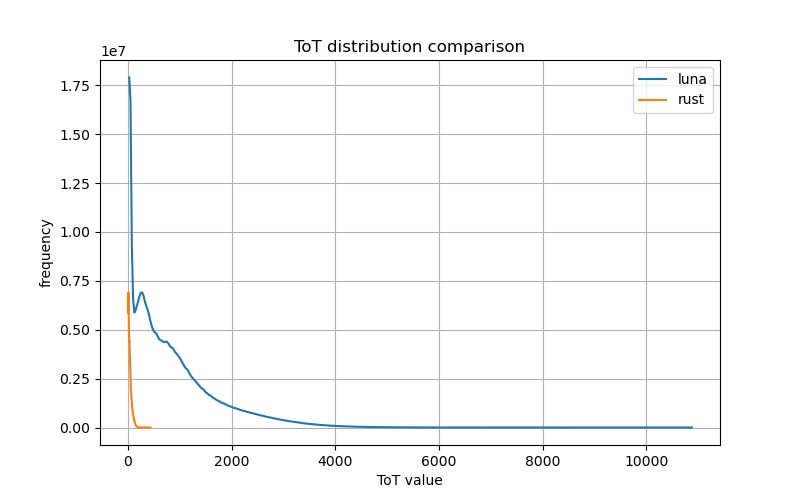

In [14]:
%matplotlib widget

# frequency per exact value
vals1, freq1 = np.unique(tot1, return_counts=True)
vals2, freq2 = np.unique(tot2, return_counts=True)

# sum of ToT
sum1 = np.sum(freq1)
sum2 = np.sum(freq2)

print("sum no. tot file1:", sum1)
print("sum no. tot file2:", sum2)

# plot
plt.figure(figsize=(8,5))
plt.plot(vals1, freq1, label="luna")
plt.plot(vals2, freq2, label="rust")

plt.xlabel("ToT value")
plt.ylabel("frequency")
plt.title("ToT distribution comparison")

plt.legend()
plt.grid(True)

plt.show()

515
1035


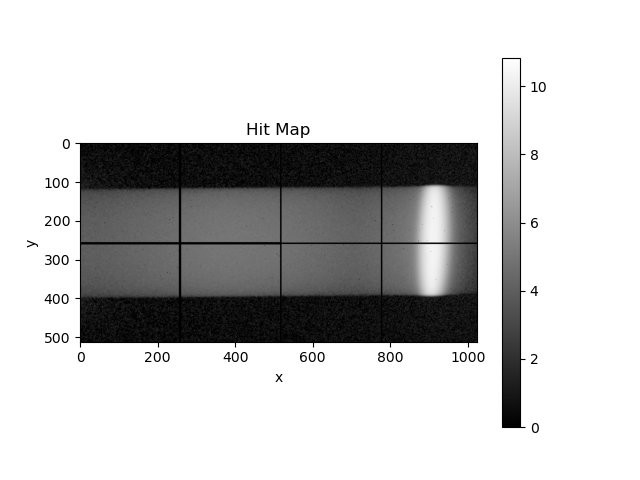

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Create empty 512x512 grid
energy_distribution = np.zeros((512, 1024), dtype=np.int64)

# Convert to NumPy arrays
y_vals = y
x_vals = x
print(max(y_vals))
print(np.max(x_vals))

# Filter valid pixel coordinates
mask = (x_vals >= 0) & (x_vals < 1024) & (y_vals >= 0) & (y_vals < 512)
x_vals = x_vals[mask]
y_vals = y_vals[mask]

# Accumulate hits
np.add.at(energy_distribution, (y_vals, x_vals), 1)

# Plot
plt.figure()
plt.imshow(np.log(energy_distribution+1), cmap='grey')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hit Map")
plt.colorbar()
plt.show()

In [31]:
import h5py
import numpy as np

with h5py.File("output_clusters_kuttruff/output_multithread.hdf5", "r") as f:
    max_intens = f["dir/max_intens"][:]
    size = f["dir/size"][:]
    sum_intens = f["dir/sum_intens"][:]
    time = f["dir/time"][:]
    x = f["dir/x"][:]
    y = f["dir/y"][:]

print(len(x),len(y))
print(max_intens[:10])
print(size[:10])
print(x[:20],y[:20])


3379630 3379630
[ 36 114 106  57  95   7 137  72  57  94]
[ 4  3  7  6 12  1 11 12  6  7]
[920 923 807 961 927 924 957 946 942 924 944 941 937 939 931 945 949 950
 959 946] [353 275 210 177 234 231 189 319 321 201 296 311 309 317 179 172 135 328
 311 350]


In [32]:
# read h5 file
import h5py
import pandas as pd
import numpy as np

#with h5py.File('data/2x4-hits-full.hdf5', 'r') as f:
with h5py.File("hitparser_output/test-full.hdf5", "r") as f:
    hits = f['hits'][:]  # Load all hits
    ToA = hits['ToA']     # Access specific field
    x = hits['x']
    y = hits['y']
    ToT = hits['ToT']
    print(len(hits), len(ToA), len(ToT), len(x), len(y))

print(hits[0:100])
print(x,y,ToA,ToT)

296119556 296119556 296119556 296119556 296119556
[(5, 926, 355,  36, 276513) (5, 927, 356,  17, 276513)
 (5, 927, 357,  29, 276513) (5, 929, 276,  17, 276513)
 (5, 929, 277, 114, 276513) (5, 929, 356,   6, 276513)
 (5, 930, 277,  54, 276513) (7, 812, 210,  13, 276513)
 (7, 813, 210, 106, 276513) (7, 813, 211,  28, 276513)
 (7, 814, 209,  78, 276513) (7, 814, 210,  63, 276513)
 (7, 814, 211,  18, 276513) (7, 815, 209,  87, 276513)
 (7, 966, 173,   5, 276513) (7, 966, 174,  37, 276513)
 (7, 967, 177,  57, 276513) (7, 968, 175,  17, 276513)
 (7, 968, 176,  18, 276513) (7, 968, 177,  57, 276513)
 (7, 933, 234,  95, 277160) (7, 934, 234,  46, 277160)
 (7, 932, 233,   9, 277161) (7, 933, 233,  57, 277161)
 (7, 932, 232,  37, 277162) (7, 933, 232,  23, 277163)
 (7, 934, 233,  10, 277163) (7, 931, 231,  33, 277164)
 (7, 932, 231,  53, 277164) (7, 931, 232,  16, 277165)
 (7, 930, 232,  33, 277169) (7, 930, 231,   7, 277174)
 (7, 930, 233,  11, 277179) (7, 963, 189, 137, 277603)
 (7, 962, 189, 

515
1035
276513 7200292017


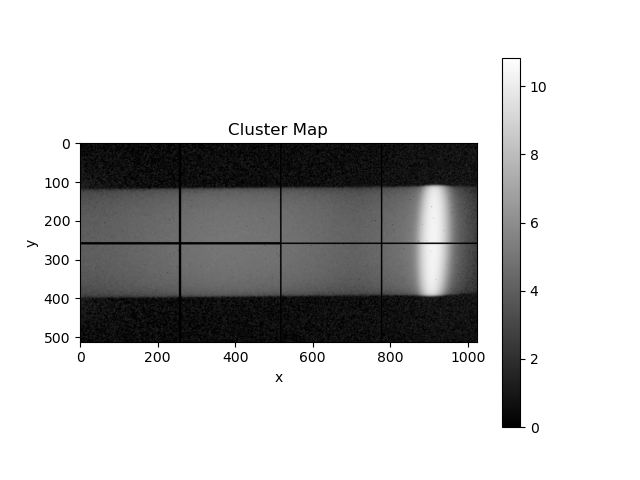

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Create empty 512x512 grid
energy_distribution = np.zeros((512, 1024), dtype=np.int64)

# Convert to NumPy arrays
y_vals = y
x_vals = x
time_vals = ToA
tot_vals = ToT
print(max(y_vals))
print(np.max(x_vals))
print(min(time_vals), max(time_vals))


# Filter valid pixel coordinates
mask = (x_vals >= 0) & (x_vals < 1024) & (y_vals >= 0) & (y_vals < 512)
x_vals = x_vals[mask]
y_vals = y_vals[mask]

# Accumulate hits
np.add.at(energy_distribution, (y_vals, x_vals), 1)

# Plot
plt.figure()
plt.imshow(np.log(energy_distribution+1), cmap='grey')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cluster Map")
plt.colorbar()

In [34]:
import numpy as np
min_len = min(len(x_vals), len(y_vals), len(time_vals))
x_vals    = np.array(x_vals[:min_len])
y_vals    = np.array(y_vals[:min_len])
time_vals = np.array(time_vals[:min_len])

# --- Find a dense region ---
# Bin the full dataset coarsely
t_bin_size = (time_vals.max() - time_vals.min()) // 20   # 20 time slices
x_bin_size = 20   # pixels per bin
y_bin_size = 20

t_bins = ((time_vals - time_vals.min()) / t_bin_size).astype(int).clip(0, 19)
x_bins = ((x_vals    - x_vals.min())    / x_bin_size).astype(int)
y_bins = ((y_vals    - y_vals.min())    / y_bin_size).astype(int)

# Count events per (x_bin, y_bin, t_bin)
from collections import Counter
counts = Counter(zip(x_bins, y_bins, t_bins))

# Find the densest bin
best_xb, best_yb, best_tb = max(counts, key=counts.get)
best_count = counts[(best_xb, best_yb, best_tb)]

# Convert back to real-world coordinates
best_x_centre = x_vals.min()    + best_xb * x_bin_size    + x_bin_size // 2
best_y_centre = y_vals.min()    + best_yb * y_bin_size    + y_bin_size // 2
best_t_centre = time_vals.min() + best_tb * t_bin_size    + t_bin_size // 2

print(f"Densest bin has {best_count} events")
print(f"  x centre : {best_x_centre}")
print(f"  y centre : {best_y_centre}")
print(f"  t centre : {best_t_centre}")

# --- Suggest plot ranges centred on that hotspot ---
hw_x, hw_y, hw_t = 25, 25, 50000   # half-widths — adjust to taste

x_range = [int(best_x_centre - hw_x), int(best_x_centre + hw_x)]
y_range = [int(best_y_centre - hw_y), int(best_y_centre + hw_y)]
t_range = [int(best_t_centre - hw_t), int(best_t_centre + hw_t)]

# Clamp to valid data bounds
x_range = [max(x_range[0], int(x_vals.min())),    min(x_range[1], int(x_vals.max()))]
y_range = [max(y_range[0], int(y_vals.min())),    min(y_range[1], int(y_vals.max()))]
t_range = [max(t_range[0], int(time_vals.min())), min(t_range[1], int(time_vals.max()))]

print(f"\nSuggested ranges:")
print(f"  x_range = {x_range}")
print(f"  y_range = {y_range}")
print(f"  t_range = {t_range}")

Densest bin has 629624 events
  x centre : 910
  y centre : 270
  t centre : 3060283100

Suggested ranges:
  x_range = [885, 935]
  y_range = [245, 295]
  t_range = [3060233100, 3060333100]


x_vals:    296077105
y_vals:    296077105
time_vals: 296077105
Trimmed to: 296077105 events


/var/folders/04/jlh9mlqn1k946gj5007pwxv00000gq/T/ipykernel_12716/538305146.py:114: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


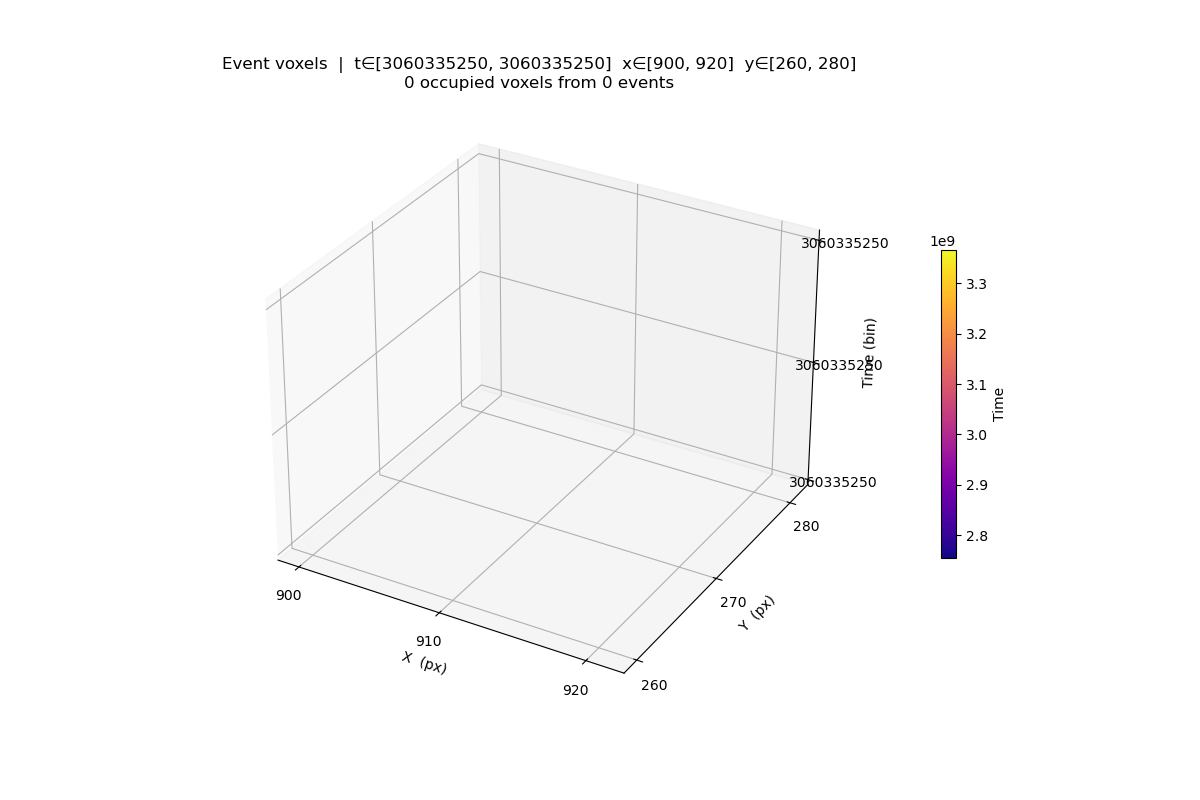

In [35]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Inspect lengths ---

t_range = [3000000, 3000100]
t_range = [526803421, 526903421]
x_range = [800, 1000]
y_range = [100, 300]
x_range = [900, 920]
y_range = [260, 280]
t_range = [3060335250, 3060335250]


print(f"x_vals:    {len(x_vals)}")
print(f"y_vals:    {len(y_vals)}")
print(f"time_vals: {len(time_vals)}")

# --- Trim all to the shortest length ---
min_len = min(len(x_vals), len(y_vals), len(time_vals))
x_vals    = np.array(x_vals[:min_len])
y_vals    = np.array(y_vals[:min_len])
time_vals = np.array(time_vals[:min_len])

print(f"Trimmed to: {min_len} events")
# --- Filter events within the specified ranges ---

x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
time_vals = np.array(time_vals)

mask = (
    (time_vals >= t_range[0]) & (time_vals <= t_range[1]) &
    (x_vals    >= x_range[0]) & (x_vals    <= x_range[1]) &
    (y_vals    >= y_range[0]) & (y_vals    <= y_range[1])
)

x_filt = x_vals[mask]
y_filt = y_vals[mask]
t_filt = time_vals[mask]

# --- Map filtered events to voxel grid indices ---
x_idx = x_filt - x_range[0]                                           # 0 .. (x_range span)
y_idx = y_filt - y_range[0]                                           # 0 .. (y_range span)
t_idx = ((t_filt - t_range[0]) /                                      # normalise to grid
         (t_range[1] - t_range[0]) * 50).astype(int)                  # 50 time bins

nx = x_range[1] - x_range[0] + 1   # 51
ny = y_range[1] - y_range[0] + 1   # 51
nt = 51                             # time bins

# --- Build boolean occupancy voxel grid ---
voxels = np.zeros((nx, ny, nt), dtype=bool)
# Clip indices to be safe
x_idx = np.clip(x_idx, 0, nx - 1)
y_idx = np.clip(y_idx, 0, ny - 1)
t_idx = np.clip(t_idx, 0, nt - 1)
voxels[x_idx, y_idx, t_idx] = True

# --- Colour voxels by time bin (cool → warm) ---
colors = np.empty(voxels.shape, dtype=object)
cmap   = plt.cm.plasma
for ti in range(nt):
    rgba = cmap(ti / max(nt - 1, 1))
    color_str = f'rgba({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)},{rgba[3]:.2f})'
    colors[:, :, ti] = color_str          # store as string; matplotlib accepts (R,G,B,A) tuples too

# Build a float RGBA array for matplotlib
facecolors = np.zeros(voxels.shape + (4,))
for ti in range(nt):
    rgba = cmap(ti / max(nt - 1, 1))
    facecolors[:, :, ti] = rgba

# --- Plot ---
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.voxels(
    voxels,
    facecolors=np.where(voxels[..., np.newaxis], facecolors, 0),
    edgecolors=None,
    alpha=0.6
)

# --- Labels ---
ax.set_xlabel('X  (px)')
ax.set_ylabel('Y  (px)')
ax.set_zlabel('Time (bin)')

# Tick labels → real-world values
ax.set_xticks([0, nx//2, nx-1])
ax.set_xticklabels([x_range[0], (x_range[0]+x_range[1])//2, x_range[1]])

ax.set_yticks([0, ny//2, ny-1])
ax.set_yticklabels([y_range[0], (y_range[0]+y_range[1])//2, y_range[1]])

ax.set_zticks([0, nt//2, nt-1])
ax.set_zticklabels([t_range[0], (t_range[0]+t_range[1])//2, t_range[1]])

ax.set_title(
    f'Event voxels  |  t∈{t_range}  x∈{x_range}  y∈{y_range}\n'
    f'{voxels.sum()} occupied voxels from {mask.sum()} events'
)

# Colourbar
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=t_range[0], vmax=t_range[1]))
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.1, label='Time')

plt.tight_layout()
plt.show()

296077105 3379630
61053.0 23263.0
33299.0 11804.0
34042.0 11825.0
34621.0 11887.0
39794.0 11902.0
36204.0 11543.0
36140.0 11396.0
32857.0 11585.0
29118.0 11572.0
32662.0 11653.0
37142.0 11890.0
36656.0 11863.0
41375.0 11914.0
40636.0 12005.0
38275.0 11876.0
34473.0 12083.0
32115.0 12192.0
31916.0 11933.0
34212.0 11727.0
31240.0 11745.0
30916.0 11667.0
30724.0 11625.0
31138.0 11595.0
35023.0 11835.0
35886.0 12073.0
32209.0 12099.0
32096.0 11904.0
32507.0 12283.0
37190.0 12263.0
36546.0 12014.0
35386.0 12148.0
37794.0 12224.0
37289.0 12104.0
37720.0 12242.0
33451.0 12414.0
34749.0 12310.0
36043.0 12046.0
32731.0 11865.0
37981.0 11985.0
37220.0 11924.0
36306.0 12050.0
39348.0 11901.0
36364.0 11933.0
35518.0 12010.0
35212.0 11953.0
33604.0 12120.0
35957.0 12095.0
38008.0 12199.0
37960.0 12279.0
39006.0 12356.0
38997.0 12367.0
41690.0 12397.0
44474.0 12342.0
41563.0 12475.0
43688.0 12388.0
44290.0 12567.0
42749.0 12772.0
39615.0 12815.0
39311.0 12877.0
41189.0 12778.0
38764.0 12586.0
38098.

/var/folders/04/jlh9mlqn1k946gj5007pwxv00000gq/T/ipykernel_12716/2453436436.py:22: RuntimeWarning: invalid value encountered in scalar divide
  energy[i] = enr/number[i]
/var/folders/04/jlh9mlqn1k946gj5007pwxv00000gq/T/ipykernel_12716/2453436436.py:36: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(number))


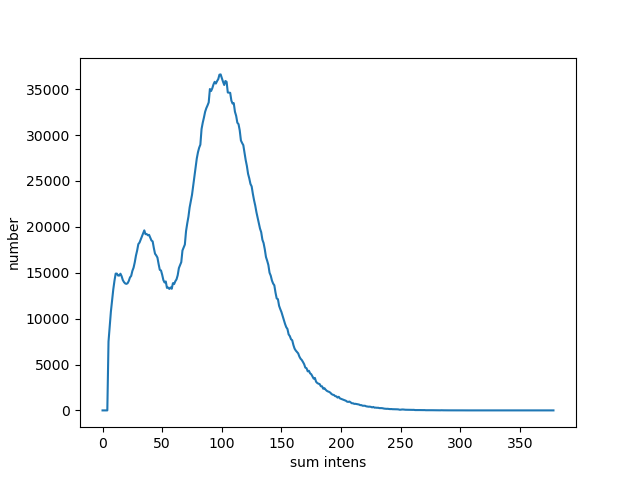

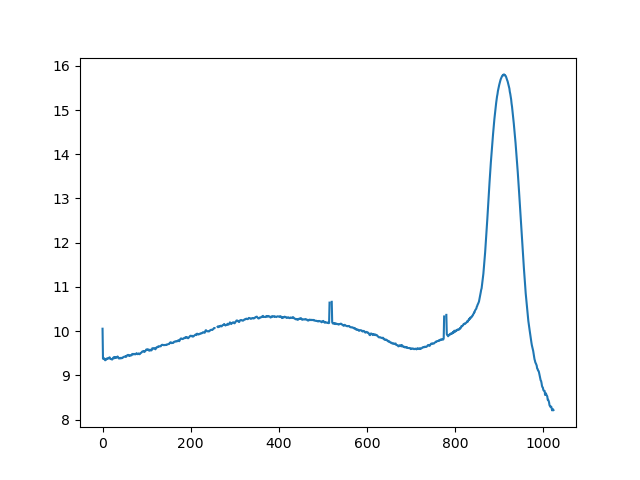

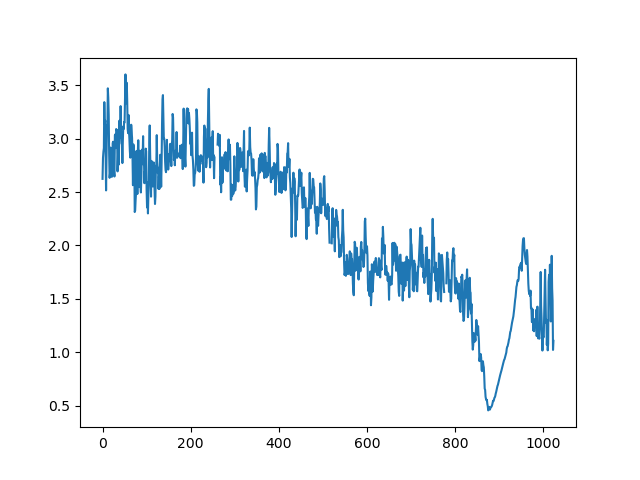

In [36]:
import numpy as np
import matplotlib.pyplot as plt

sum_intens = np.array(max_intens)
energy_distribution = np.zeros(np.max(sum_intens)+1)

number = np.zeros(np.max(x_vals)+1)
np.add.at(number,(x_vals), 1)

grid2_copy = np.zeros(np.max(x_vals)+1)
print(len(x_vals), len(sum_intens))

for i, intens in enumerate(sum_intens):
    try:
        grid2_copy[x_vals[i]] += intens
    except:
        pass
energy = grid2_copy

for i, enr in enumerate(energy):
    print(enr,number[i])
    energy[i] = enr/number[i]


# Accumulate hits
np.add.at(energy_distribution, (sum_intens), 1)

# Plot
plt.figure()
plt.plot(energy_distribution)
plt.xlabel("sum intens")
plt.ylabel("number")

plt.figure()
print(number,energy)
plt.plot(np.log(number))
plt.figure()
plt.plot(energy)


Text(0, 0.5, 'number')

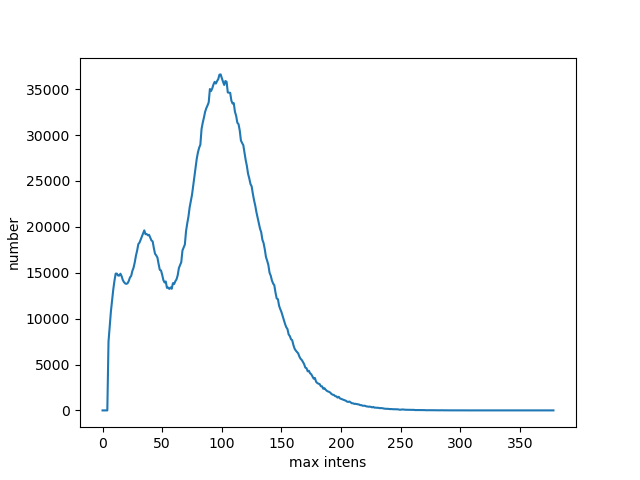

In [37]:
import numpy as np
import matplotlib.pyplot as plt

max_intens = np.array(max_intens)
energy_distribution = np.zeros(np.max(max_intens)+1)

# Accumulate hits
np.add.at(energy_distribution, (max_intens), 1)

# Plot
plt.figure()
plt.plot(energy_distribution)
plt.xlabel("max intens")
plt.ylabel("number")

In [38]:
import h5py
import numpy as np

with h5py.File("data/radial_distribution3.h5", "r") as f:
    deg_90 = pd.DataFrame({k: f[k][:1000000] for k in f.keys()})

summed_detector90 = np.zeros((512, 1024), dtype=np.uint32)
np.add.at(summed_detector90, (deg_90['cy'][:1000000].values, deg_90['cx'][:1000000].values), 1)



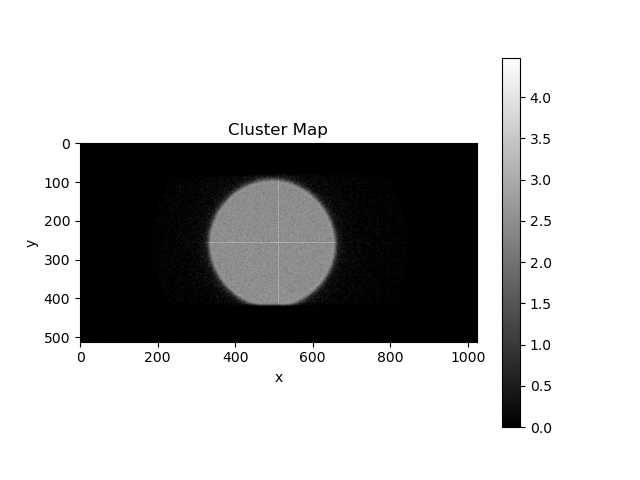

In [39]:

plt.figure()
plt.imshow(np.log(summed_detector90+1), cmap='grey')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cluster Map")
plt.colorbar()

In [40]:
# reading TPX3 files:
with open("data_tpx/raw_events_1kx1k_10us_30mhits.tpx3","rb") as f:
    data = f.read()

row_size = 8 #bytes
matches = []

for i in range(0, len(data)//10, row_size):
    chunk = data[i:i+row_size]
    if chunk[-1:] == bytes.fromhex("6f"):
        matches.append(i)

print(matches)

[48047248, 48075520, 48228632, 48260776, 50735480, 50797536, 50886440, 50905720, 53424544, 53481288, 53500864, 53583120, 56099240, 56123864, 56246464, 56285464, 58773376, 58814328, 58836272, 58894312, 61449216, 61479368, 61654520, 61676048, 64124096, 64249216, 64295800, 64319304, 66805808, 66819776, 66876824, 66879888, 69479328, 69485480, 69662352, 69691600, 72171696, 72233656, 72236040, 72355688, 74872920, 74967760, 75031976, 75052712, 77546280, 77558896, 77603336, 77624264, 80245024, 80253736, 80421288, 80423240, 82949168, 83012104, 83033800, 83062408, 85647392, 85661600, 85800280, 85883384, 88378440, 88465760, 88556680, 88596064, 91069448, 91078824, 91149080, 91197736, 93777856, 93833128, 93897056, 94002912, 96440344, 96447768, 96554888, 96628488, 99155504, 99198680, 99273936, 99388504, 101846424, 101911992, 101967208, 102060176, 104571152, 104579104, 104635568, 104803760, 107293488, 107396048, 107434000, 107436216, 109980784, 110005200, 110026648, 110028336, 112680624, 112832296, 1

In [41]:
from collections import Counter

HEADER_MAGIC = b'TPX3'
WORD_SIZE = 8

def classify_word(word: bytes) -> str:
    high_nibble = (word[-1] >> 4) & 0xF
    match high_nibble:
        case 0xa: return "TPX3 pixel data (count_fb)"
        case 0xb: return "TPX3 pixel data (other)"
        case 0x6: return "SPIDR TDC"
        case 0x4: return "TPX3 global time"
        case 0x5: return "SPIDR control"
        case 0x7: return "TPX3 control"
        case _:   return f"Unknown (0x{high_nibble:x})"

def count_word_types(filepath: str):
    with open(filepath, "rb") as f:
        data = f.read()

    counts = Counter()
    chunks_found = 0
    i = 0
    n_heads = 0


    while i <= len(data) - WORD_SIZE:
        # Look for chunk header
        if data[i:i+4] == HEADER_MAGIC:
            n_bytes = int.from_bytes(data[i+6:i+8], "little")
            n_words = n_bytes//8
            chunks_found += 1
            i += WORD_SIZE  # skip the header
            n_heads += 1

            # Classify each word in this chunk
            for _ in range(n_words):
                if i + WORD_SIZE > len(data):
                    break
                word = data[i:i+WORD_SIZE]
                counts[classify_word(word)] += 1
                i += WORD_SIZE
        else:
            print(f"Warning: lost sync at byte {i}")
            next_header = data.find(HEADER_MAGIC, i + 1)
            if next_header == -1:
                break
            print(f"  Next header found at: {next_header} (gap of {next_header - i} bytes)")
            i = next_header

    print(f"Length of data: (8 byte packets) {len(data)//8:,}")
    print(f"Chunks parsed: {chunks_found:,}")
    print(f"Total words:   {sum(counts.values()):,}")
    print("\n=== Word type counts ===")
    for label, count in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {label}: {count:,}")

    return counts

counts = count_word_types("data_tpx/raw_events_1kx1k_10us_30mhits.tpx3")

Length of data: (8 byte packets) 348,791,700
Chunks parsed: 360,365
Total words:   348,431,335

=== Word type counts ===
  TPX3 pixel data (other): 346,985,327
  SPIDR control: 1,441,912
  SPIDR TDC: 4,096


In [42]:
print(f"Length of data: (chunks) {len(data)//8:,}")


Length of data: (chunks) 348,791,700


In [43]:
348431335 * 8

2787450680

In [44]:
2790333600/8

348791700.0

In [45]:
print(min(data1["tot"]), min(data2["tot"]))

5 5


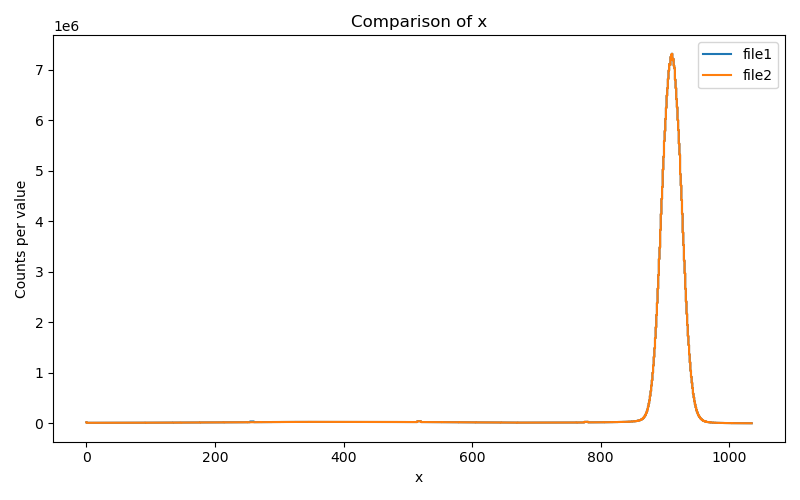

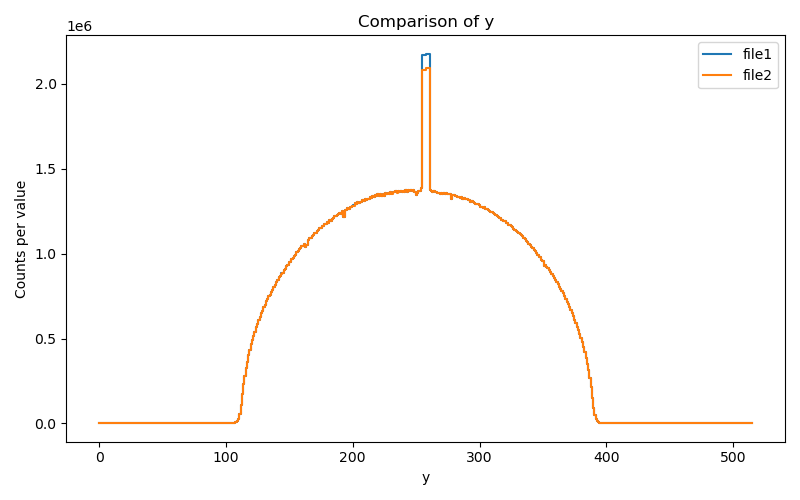

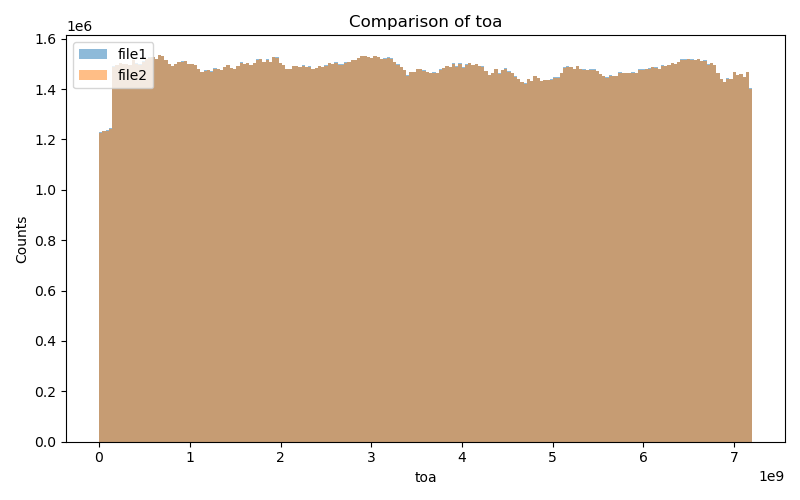

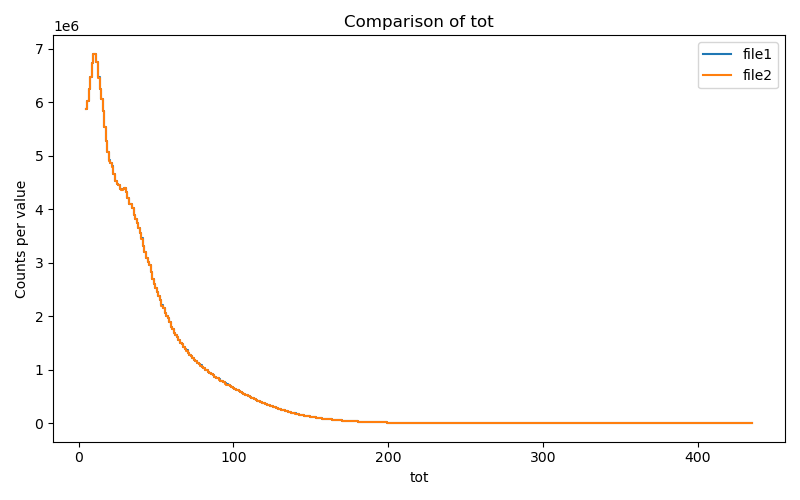

In [46]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# File paths
file1 = "output_clusters_kuttruff/test_hits_small_sort_window.hdf5"
# file1 = "output_clusters_kuttruff/test_hits_large_sort_window.hdf5"
file1 = "output_clusters_kuttruff/test_hits_no_sort.hdf5"


file2 = "hitparser_output/test-full-reorganised.hdf5"

# Fields to compare
fields = ["x", "y", "toa", "tot"]

# Load datasets
def load_data(path, fields):
    data = {}
    with h5py.File(path, "r") as f:
        for field in fields:
            data[field] = f[field][:]
    return data

data1 = load_data(file1, fields)
data2 = load_data(file2, fields)

# Plot comparison
for field in fields:
    plt.figure(figsize=(8, 5))
    if field == "toa":
        # Regular histogram for ToA
        bins = 200  # adjust if needed
        plt.hist(data1[field], bins=bins, alpha=0.5, label="file1", density=False)
        plt.hist(data2[field], bins=bins, alpha=0.5, label="file2", density=False)
        plt.xlabel(field)
        plt.ylabel("Counts")
    else:
        # Count per unique value
        vals1, counts1 = np.unique(data1[field], return_counts=True)
        vals2, counts2 = np.unique(data2[field], return_counts=True)
        plt.plot(vals1, counts1, label="file1", drawstyle='steps-mid')
        plt.plot(vals2, counts2, label="file2", drawstyle='steps-mid')
        plt.xlabel(field)
        plt.ylabel("Counts per value")
    
    plt.title(f"Comparison of {field}")
    plt.legend()
    plt.tight_layout()
    plt.show()

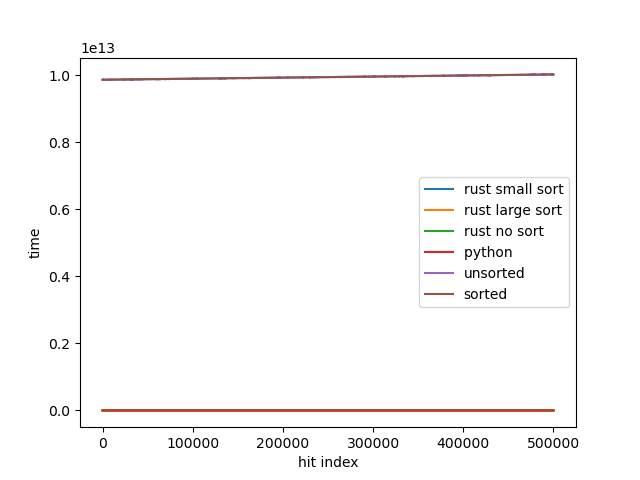

In [18]:
%matplotlib widget
# --- Compare time differences between consecutive hits (counts, log scale) ---
# File paths
file1 = "output_clusters_kuttruff/test_hits_small_sort_window.hdf5"
file2 = "output_clusters_kuttruff/test_hits_large_sort_window.hdf5"
file3 = "output_clusters_kuttruff/test_hits_no_sort.hdf5"

file4 = "hitparser_output/test-full-reorganised.hdf5"

# Fields to compare
fields = ["x", "y", "toa", "tot"]

# Load datasets
def load_data(path, fields):
    data = {}
    with h5py.File(path, "r") as f:
        for field in fields:
            data[field] = f[field][:]
    return data


with h5py.File("hyperparameters/raw_events_1kx1k_10us_30mhits_unsorted.h5", "r") as f:
    hits = f["PixelHits"]

    # convert structured array to numpy
    arr = hits[:]

    # column index 2
    data5 = np.array(arr[arr.dtype.names[0]])

with h5py.File("hyperparameters/raw_events_1kx1k_10us_30mhits_sorted.h5", "r") as f:
    hits = f["PixelHits"]

    # convert structured array to numpy
    arr = hits[:]

    # column index 2
    data6 = np.array(arr[arr.dtype.names[0]])

data1 = load_data(file1, fields)
data2 = load_data(file2, fields)
data3 = load_data(file3, fields)
data4 = load_data(file4, fields)

# # compute time differences
# toa_diff1 = data1["toa"] - np.roll(data1["toa"], 1)
# toa_diff2 = data2["toa"] - np.roll(data2["toa"], 1)

# # remove wraparound artefact
# toa_diff1 = toa_diff1[1:]
# toa_diff2 = toa_diff2[1:]

# # count occurrences of each delta value
# vals1, counts1 = np.unique(toa_diff1, return_counts=True)
# vals2, counts2 = np.unique(toa_diff2, return_counts=True)

# # plot
# plt.figure(figsize=(8,5))

# plt.plot(vals1, counts1, label="rust code", drawstyle="steps-mid")
# plt.plot(vals2, counts2, label="python code", drawstyle="steps-mid")

# # plt.yscale("log")

# plt.xlabel("ΔToA between consecutive hits")
# plt.ylabel("Counts (log scale)")
# plt.xlim([-5e4,5e4])
# plt.title("Time difference between hits (log counts)")
# plt.legend()
# plt.tight_layout()

# print("Mean ΔToA file1:", np.mean(toa_diff1))
# print("Mean ΔToA file2:", np.mean(toa_diff2))

# plt.show()

start1 = int(len(data1["toa"]) * 0.1)
start2 = int(len(data2["toa"]) * 0.1)
start3 = int(len(data1["toa"]) * 0.1)
start4 = int(len(data2["toa"]) * 0.1)

plt.figure()
plt.plot(data1["toa"][start1:start1+500000], label="rust small sort")
plt.plot(data2["toa"][start2:start2+500000]+0.001e8, label="rust large sort")
plt.plot(data3["toa"][start3:start3+500000]+0.002e8, label="rust no sort")
plt.plot(data4["toa"][start4:start4+500000]-0.003e8, label="python ")
plt.plot(data5[start4:start4+500000]+200e6, label="unsorted")
plt.plot(data6[start4:start4+500000]+250e6, label="sorted")


plt.xlabel("hit index")
plt.ylabel("time")
plt.legend()


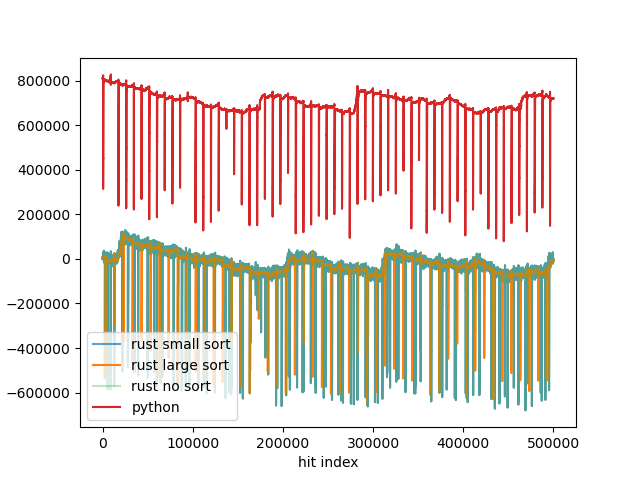

In [51]:
import numpy as np
import matplotlib.pyplot as plt

file1 = "output_clusters_kuttruff/test_hits_small_sort_window.hdf5"
file2 = "output_clusters_kuttruff/test_hits_large_sort_window.hdf5"
file3 = "output_clusters_kuttruff/test_hits_no_sort.hdf5"


file4 = "hitparser_output/test-full-reorganised.hdf5"

# Fields to compare
fields = ["x", "y", "toa", "tot"]

# Load datasets
def load_data(path, fields):
    data = {}
    with h5py.File(path, "r") as f:
        for field in fields:
            data[field] = f[field][:]
    return data

data1 = load_data(file1, fields)
data2 = load_data(file2, fields)
data3 = load_data(file3, fields)
data4 = load_data(file4, fields)



def subtract_reference_line(reference_array, target_array):
    """
    reference_array: array used to define expected linear trend
    target_array: array from which the trend will be subtracted
    """

    n = len(reference_array)

    # first and last points of reference
    y0 = reference_array[0]
    y1 = reference_array[-1]

    # create straight line between them
    expected_line = np.linspace(y0, y1, n)

    # subtract trend
    return target_array - expected_line


start1 = int(len(data1["toa"]) * 0.1)
start2 = int(len(data2["toa"]) * 0.1)

# slice region to compare
ref = data1["toa"][start1:start1+500000]

dev1 = subtract_reference_line(ref, data1["toa"][start1:start1+500000])
dev2 = subtract_reference_line(ref, data2["toa"][start2:start2+500000])
dev3 = subtract_reference_line(ref, data3["toa"][start1:start1+500000])
dev4 = subtract_reference_line(ref, data4["toa"][start2:start2+500000])

plt.figure()
plt.plot(dev1, label="rust small sort", alpha=0.7)
plt.plot(dev2, label="rust large sort")
plt.plot(dev3, label="rust no sort", alpha = 0.3)
plt.plot(dev4, label="python")

plt.xlabel("hit index")
plt.ylabel("deviation from linear time")
plt.legend()

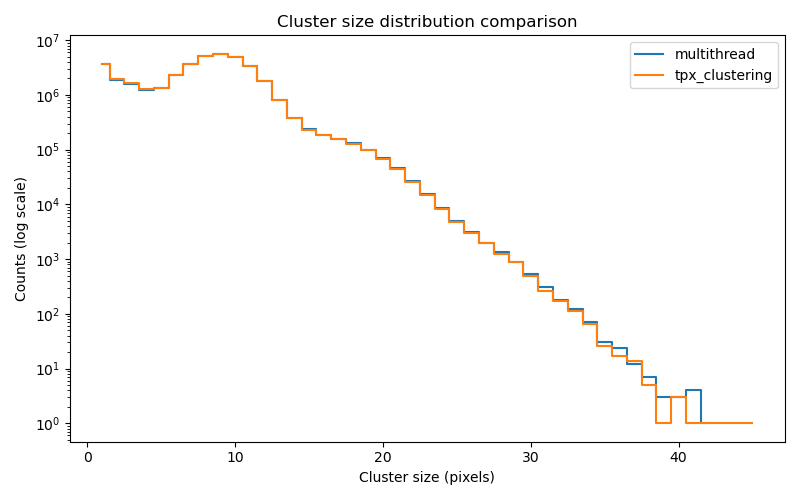

Mean cluster size multithread: 7.645062345225788
Mean cluster size tpx_clustering: 7.616367705225621
Total clusters multithread: 38733439
Total clusters tpx_clustering: 38911930


In [48]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file1 = "output_clusters_kuttruff/output_multithread-full.hdf5"
file2 = "output_clusters_kuttruff/output_tpx_clustering3.hdf5"

# load cluster sizes
with h5py.File(file1, "r") as f:
    size1 = f["dir/size"][:]

with h5py.File(file2, "r") as f:
    size2 = f["dir/size"][:]

# count occurrences
vals1, counts1 = np.unique(size1, return_counts=True)
vals2, counts2 = np.unique(size2, return_counts=True)

# plot
plt.figure(figsize=(8,5))

plt.plot(vals1, counts1, label="multithread", drawstyle="steps-mid")
plt.plot(vals2, counts2, label="tpx_clustering", drawstyle="steps-mid")

plt.yscale("log")

plt.xlabel("Cluster size (pixels)")
plt.ylabel("Counts (log scale)")
plt.title("Cluster size distribution comparison")

plt.legend()
plt.tight_layout()
plt.show()

# quick sanity check
print("Mean cluster size multithread:", np.mean(size1))
print("Mean cluster size tpx_clustering:", np.mean(size2))
print("Total clusters multithread:", len(size1))
print("Total clusters tpx_clustering:", len(size2))

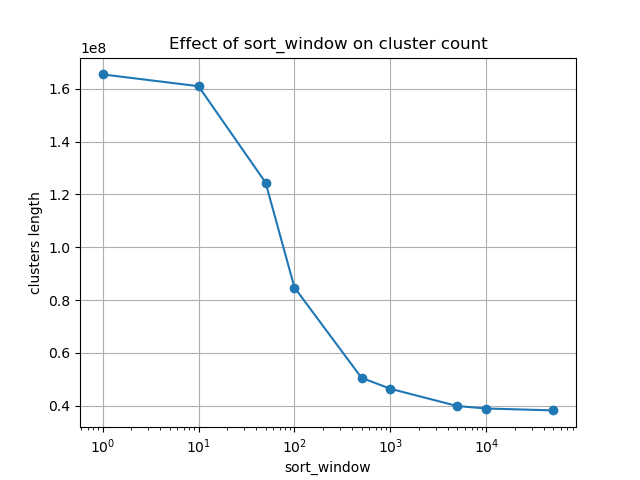

In [54]:
import matplotlib.pyplot as plt

sort_window = [1, 10, 50, 100, 500, 1000, 5000, 10000, 50000]

clusters_len = [
    165460337,
    160991366,
    124482985,
    84738561,
    50534869,
    46378392,
    39827780,
    38911930,
    38193331
]

plt.figure()
plt.plot(sort_window, clusters_len, marker="o")

plt.xlabel("sort_window")
plt.ylabel("clusters length")
plt.title("Effect of sort_window on cluster count")

plt.xscale("log")  # helpful since values span several orders of magnitude
plt.grid(True)

plt.show()

✓ Loaded ./hyperparameters/events_sw_10.hdf5: plotted events [148158783:148208783] from 296367567 total
✓ Loaded ./hyperparameters/events_sw_100.hdf5: plotted events [148158783:148208783] from 296367567 total
✓ Loaded ./hyperparameters/events_sw_1000.hdf5: plotted events [148158783:148208783] from 296367567 total
✓ Loaded ./hyperparameters/events_sw_10000.hdf5: plotted events [148158783:148208783] from 296367567 total
✓ Loaded ./hyperparameters/events_sw_10000000000.hdf5: plotted events [148158783:148208783] from 296367567 total


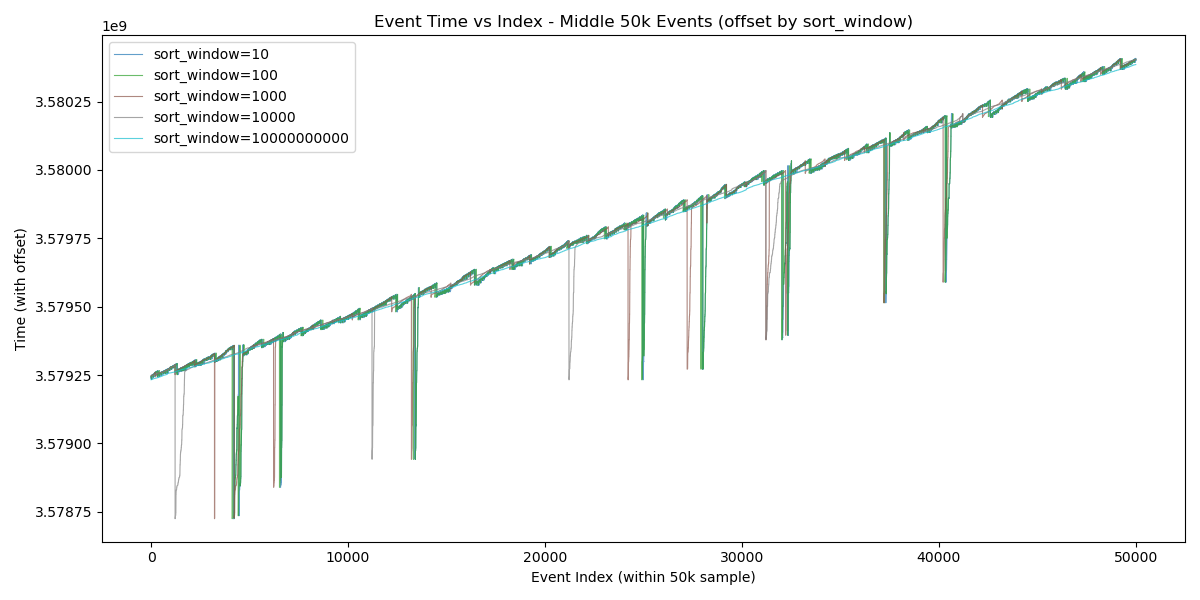

In [3]:
%matplotlib widget
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob

# Find all event files
event_files = sorted(glob.glob("./hyperparameters/events_sw_10*.hdf5"))

if not event_files:
    print("No event files found in ./hyperparameters/")
    exit()

plt.figure(figsize=(12, 6))

# Color map for different files
colors = plt.cm.tab10(np.linspace(0, 1, len(event_files)))

for idx, filepath in enumerate(event_files):
    try:
        with h5py.File(filepath, "r") as f:
            time = f["toa"][:] if "toa" in f else f["time"][:]
        
        # Extract middle 50,000 values
        n_events = len(time)
        start_idx = (n_events - 50000) // 2
        end_idx = start_idx + 50000
        time_slice = time[start_idx:end_idx]
        
        # Create slight offset for visibility
        offset = idx   # Adjust offset magnitude as needed
        
        # Plot with label showing sort_window
        sort_window = filepath.split("sw_")[1].split(".")[0]
        plt.plot(time_slice + offset, label=f"sort_window={sort_window}", 
                alpha=0.7, color=colors[idx], linewidth=0.8)
        
        print(f"✓ Loaded {filepath}: plotted events [{start_idx}:{end_idx}] from {n_events} total")
    
    except Exception as e:
        print(f"✗ Error loading {filepath}: {e}")

plt.xlabel("Event Index (within 50k sample)")
plt.ylabel("Time (with offset)")
plt.title("Event Time vs Index - Middle 50k Events (offset by sort_window)")
plt.legend(loc='best')
plt.tight_layout()
plt.show()